## Find some interesting sea breeze cases for Illawarra based on SST variations from BARRA-C2

In [1]:
import pandas as pd
import xarray as xr
from sea_breeze.load_model_data import (load_aus2200_variable, 
interp_model_level_to_z, load_aus2200_static, aus2200_hybrid_height_calc, load_barra_static, load_barra_variable)
from sea_breeze.sea_breeze_funcs import rotate_wind
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from dask.distributed import Client
from metpy.interpolate import cross_section
import metpy.calc as mpcalc
import metpy.units as units
import numpy as np

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33339,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42741,Total threads: 1
Dashboard: /proxy/42331/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:36927,


In [3]:
#Load sea breeze day dataset
region="illawara"
sb_day = pd.read_csv("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/sb_days/"+region+".csv")
sb_dates = pd.to_datetime(sb_day[sb_day.sb==1]["time"].values)

In [8]:
sb_dates[sb_dates.year==2017]

DatetimeIndex(['2017-01-06', '2017-01-07', '2017-01-08', '2017-01-09',
               '2017-01-10', '2017-01-11', '2017-01-13', '2017-01-14',
               '2017-01-15', '2017-01-16',
               ...
               '2017-12-14', '2017-12-16', '2017-12-18', '2017-12-19',
               '2017-12-20', '2017-12-23', '2017-12-24', '2017-12-28',
               '2017-12-29', '2017-12-30'],
              dtype='datetime64[ns]', length=122, freq=None)

In [6]:
lat_slice = slice(-36,-33)
lon_slice = slice(149,152)

def preprocess(ds):
    lat_slice = slice(-36,-33)
    lon_slice = slice(149,152)
    return ds.sel(lat=lat_slice,lon=lon_slice) - 273.15

barra_ts = xr.open_mfdataset(
    "/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ts/latest/ts_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1_1hr_????10*.nc",
    chunks={"time":-1,"lat":-1,"lon":-1},preprocess=preprocess).persist()

barra_ts_daily = barra_ts.groupby(barra_ts.time.dt.date).mean()
barra_ts_sb = barra_ts_daily.sel(date=np.in1d(pd.to_datetime(barra_ts_daily.date),sb_dates)).ts.persist()

In [7]:
rez_shapes = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/rez_coastal_shapes.nc").sel(lat=lat_slice,lon=lon_slice)

In [8]:
ocean = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/sftlf/latest/sftlf_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc").\
sel(lat=lat_slice,lon=lon_slice).sftlf == 0

In [9]:
barra_ts_sb_ocean = xr.where(ocean,barra_ts_sb,np.nan)

In [10]:
max_sst = barra_ts_sb_ocean.max(("lat","lon")).to_dataframe(name="max")[["max"]]
min_sst = barra_ts_sb_ocean.min(("lat","lon")).to_dataframe(name="min")[["min"]]
mean_sst = barra_ts_sb_ocean.mean(("lat","lon")).to_dataframe(name="mean")[["mean"]]
max_minus_min = (max_sst["max"]-min_sst["min"]).rename("max_minus_min")

In [11]:
land_sea_diff_illawara = pd.read_csv("/g/data/ng72/ab4502/coastline_data/land_sea_temp_diff_barra_c_rez/illawara.csv",index_col=0).loc[slice("1979-01-01","2024-12-31 23:00")]
land_sea_diff_illawara = land_sea_diff_illawara.set_index(pd.to_datetime(land_sea_diff_illawara.index))
land_sea_diff_illawara = land_sea_diff_illawara.loc[np.in1d(pd.to_datetime(land_sea_diff_illawara.index),sb_dates)].rename(columns={"0":"land_sea_diff"})
land_sea_diff_illawara = land_sea_diff_illawara.set_index(land_sea_diff_illawara.index.date)

In [12]:
sst_stats = pd.concat([mean_sst,max_sst,min_sst,max_minus_min,land_sea_diff_illawara],axis=1,join="inner")

In [13]:
land_sea_temp_diff_bins = pd.cut(sst_stats.land_sea_diff,bins=np.arange(2,12.5,0.5))

In [14]:
for n, g in sst_stats.groupby(land_sea_temp_diff_bins):
    print(n, g.shape)
    if g.shape[0]>0:
        print(g.sort_values("mean").iloc[0])
        print("\n")
        print(g.sort_values("mean").iloc[-1])
        print("\n")

(2.0, 2.5] (49, 5)
mean             16.815303
max              18.193750
min              14.225000
max_minus_min     3.968750
land_sea_diff     2.091730
Name: 1996-10-03, dtype: float64


mean             20.238096
max              21.381250
min              18.068750
max_minus_min     3.312500
land_sea_diff     2.440305
Name: 2016-10-02, dtype: float64


(2.5, 3.0] (49, 5)
mean             16.523937
max              18.225000
min              14.725000
max_minus_min     3.500000
land_sea_diff     2.833671
Name: 1984-10-02, dtype: float64


mean             20.603077
max              22.162500
min              19.506250
max_minus_min     2.656250
land_sea_diff     2.930356
Name: 2013-10-15, dtype: float64


(3.0, 3.5] (72, 5)
mean             16.568476
max              18.225000
min              14.818750
max_minus_min     3.406250
land_sea_diff     3.303090
Name: 1984-10-03, dtype: float64


mean             20.555042
max              22.100000
min              17.850000
max_minus_mi

/jobfs/154649545.gadi-pbs/ipykernel_1592457/929398811.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for n, g in sst_stats.groupby(land_sea_temp_diff_bins):


In [16]:
sst_stats.sort_values("mean").loc[pd.to_datetime("1995-10-01").date()]

mean             16.201095
max              17.318750
min              14.443750
max_minus_min     2.875000
land_sea_diff     6.434689
Name: 1995-10-01, dtype: float64

In [17]:
sst_stats.sort_values("mean").loc[pd.to_datetime("2013-10-12").date()]

mean             20.699050
max              22.537500
min              18.881250
max_minus_min     3.656250
land_sea_diff     6.131951
Name: 2013-10-12, dtype: float64

In [18]:
def load_barra_c2_data(t):

    ts = load_barra_variable( 
        "ts",t.replace(hour=0),t.replace(hour=23),"AUST-04","1hr",slice(-36,-33),slice(149,152))- 273.15
    uas = load_barra_variable(
        "uas",t.replace(hour=0),t.replace(hour=23),"AUST-04","1hr",slice(-36,-33),slice(149,152))
    vas = load_barra_variable(
        "vas",t.replace(hour=0),t.replace(hour=23),"AUST-04","1hr",slice(-36,-33),slice(149,152))

    return ts, uas, vas



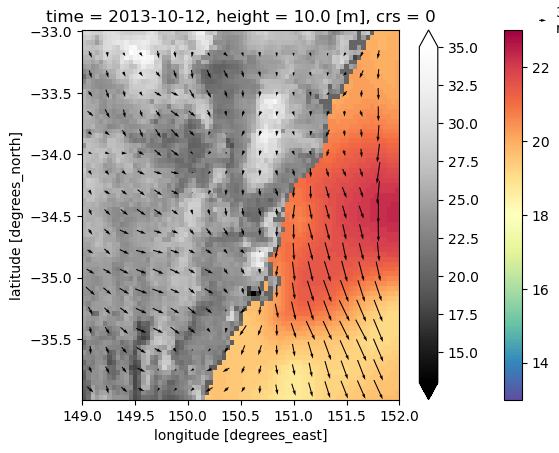

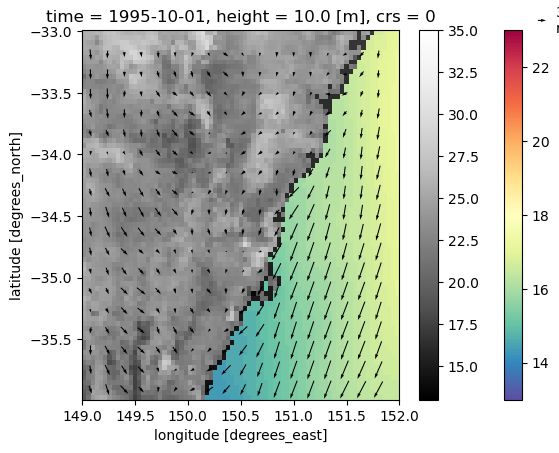

In [19]:
h=0

ts, uas, vas = load_barra_c2_data(pd.to_datetime("2013-10-12"))
xr.where(ocean,ts,np.nan).isel(time=h).plot(vmin=13,vmax=23,cmap="Spectral_r")
xr.where(ocean,np.nan,ts).isel(time=h).plot(cmap="Greys_r",vmin=13,vmax=35)
xr.Dataset({"u":uas,"v":vas}).isel(time=h).coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

plt.figure()
ts, uas, vas = load_barra_c2_data(pd.to_datetime("1995-10-01"))
xr.where(ocean,ts,np.nan).isel(time=h).plot(vmin=13,vmax=23,cmap="Spectral_r")
xr.where(ocean,np.nan,ts).isel(time=h).plot(cmap="Greys_r",vmin=13,vmax=35)
xr.Dataset({"u":uas,"v":vas}).isel(time=h).coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

In [20]:
sb_dates_3_3p5 = sst_stats[(sst_stats.land_sea_diff>=3) & (sst_stats.land_sea_diff<3.5)]

In [40]:
sst_stats.shape

(713, 5)

In [21]:
sb_dates_3_3p5_warm = sb_dates_3_3p5[sb_dates_3_3p5["mean"] >= sb_dates_3_3p5["mean"].median()]
sb_dates_3_3p5_cold = sb_dates_3_3p5[sb_dates_3_3p5["mean"] < sb_dates_3_3p5["mean"].median()]

In [22]:
ts_warm = []
uas_warm = []
vas_warm = []
for d in sb_dates_3_3p5_warm.index:
    ts, uas, vas = load_barra_c2_data(pd.to_datetime(d))
    ts_warm.append(ts)
    uas_warm.append(uas)
    vas_warm.append(vas)
ts_warm = xr.concat(ts_warm,dim="time")
uas_warm = xr.concat(uas_warm,dim="time")
vas_warm = xr.concat(vas_warm,dim="time")

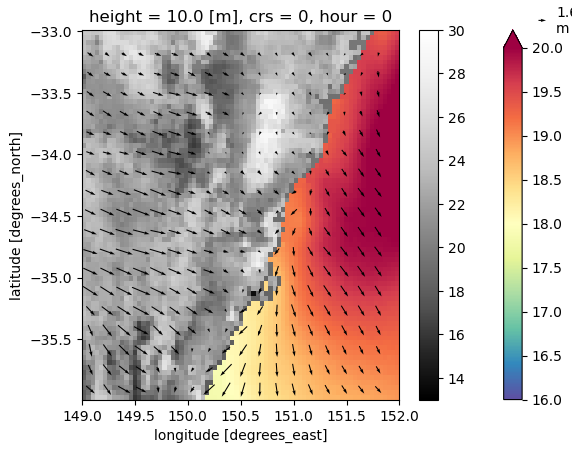

In [48]:
temp = ts_warm.groupby(ts_warm.time.dt.hour).mean().sel(hour=0)

xr.where(ocean,temp,np.nan).plot(vmin=16,vmax=20,cmap="Spectral_r")
xr.where(ocean,np.nan,temp).plot(cmap="Greys_r",vmin=13,vmax=30)

xr.Dataset({"u":uas_warm.groupby(ts_warm.time.dt.hour).mean().sel(hour=0),"v":vas_warm.groupby(ts_warm.time.dt.hour).mean().sel(hour=0)}).\
    coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

In [24]:
ts_cold = []
uas_cold = []
vas_cold = []
for d in sb_dates_3_3p5_cold.index:
    ts, uas, vas = load_barra_c2_data(pd.to_datetime(d))
    ts_cold.append(ts)
    uas_cold.append(uas)
    vas_cold.append(vas)
ts_cold = xr.concat(ts_cold,dim="time")
uas_cold = xr.concat(uas_cold,dim="time")
vas_cold = xr.concat(vas_cold,dim="time")

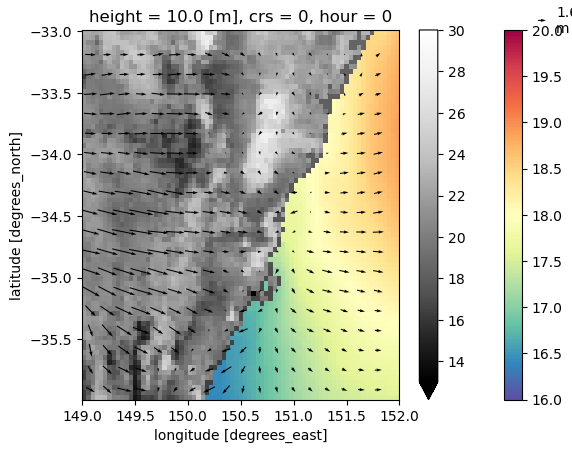

In [49]:
temp = ts_cold.groupby(ts_cold.time.dt.hour).mean().sel(hour=0)
xr.where(ocean,temp,np.nan).plot(vmin=16,vmax=20,cmap="Spectral_r")
xr.where(ocean,np.nan,temp).plot(cmap="Greys_r",vmin=13,vmax=30)

xr.Dataset({"u":uas_cold.groupby(ts_cold.time.dt.hour).mean().sel(hour=0),"v":vas_cold.groupby(ts_cold.time.dt.hour).mean().sel(hour=0)}).\
    coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

Text(0.5, 1.0, '72 sea breeze days during October with land-sea temp diff within [3.0,3.5].\nSplit into warmest and coldest SST, wind averaged\nover all sea breeze days over Illawarra offshore wind area')

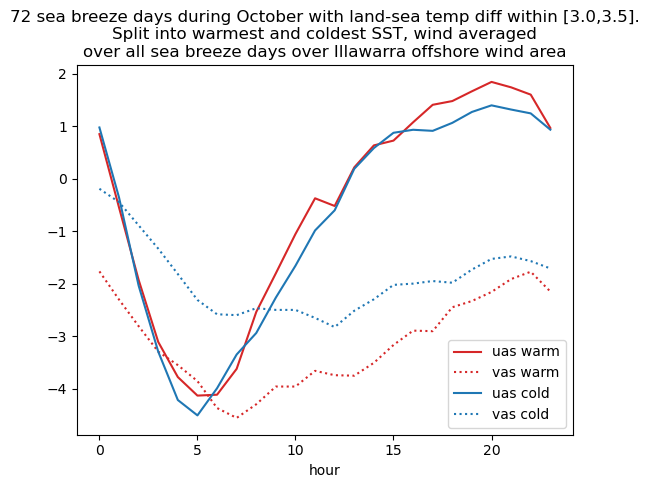

In [39]:
plt.figure()
xr.where(rez_shapes.rez_mask==19, uas_warm, np.nan).mean(("lat","lon")).groupby(uas_warm.time.dt.hour).mean().plot(label="uas warm",color="tab:red",ls="-")
xr.where(rez_shapes.rez_mask==19, vas_warm, np.nan).mean(("lat","lon")).groupby(vas_warm.time.dt.hour).mean().plot(label="vas warm",color="tab:red",ls=":")

xr.where(rez_shapes.rez_mask==19, uas_cold, np.nan).mean(("lat","lon")).groupby(uas_cold.time.dt.hour).mean().plot(label="uas cold",color="tab:blue",ls="-")
xr.where(rez_shapes.rez_mask==19, vas_cold, np.nan).mean(("lat","lon")).groupby(vas_cold.time.dt.hour).mean().plot(label="vas cold",color="tab:blue",ls=":")

plt.legend()

plt.title("72 sea breeze days during October with land-sea temp diff within [3.0,3.5].\nSplit into warmest and coldest SST, wind averaged\nover all sea breeze days over Illawarra offshore wind area")

In [30]:
large_grad_df = sst_stats[(sst_stats.land_sea_diff>=sst_stats.land_sea_diff.median())]
small_grad_df = sst_stats[(sst_stats.land_sea_diff<sst_stats.land_sea_diff.median())]

3.660967204560052

In [32]:
import tqdm

ts_large = []
uas_large = []
vas_large = []
for d in tqdm.tqdm(large_grad_df.index):
    ts, uas, vas = load_barra_c2_data(pd.to_datetime(d))
    ts_large.append(ts)
    uas_large.append(uas)
    vas_large.append(vas)
ts_large = xr.concat(ts_large,dim="time")
uas_large = xr.concat(uas_large,dim="time")
vas_large = xr.concat(vas_large,dim="time")

100%|██████████| 357/357 [00:21<00:00, 16.34it/s]


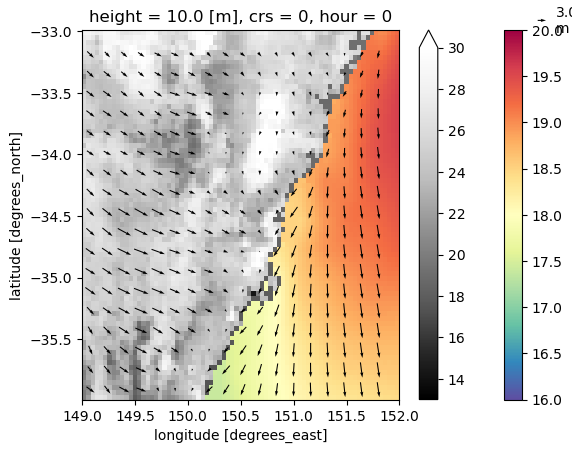

In [50]:
temp = ts_large.groupby(ts_large.time.dt.hour).mean().sel(hour=0)
xr.where(ocean,temp,np.nan).plot(vmin=16,vmax=20,cmap="Spectral_r")
xr.where(ocean,np.nan,temp).plot(cmap="Greys_r",vmin=13,vmax=30)

xr.Dataset({"u":uas_large.groupby(ts_large.time.dt.hour).mean().sel(hour=0),"v":vas_large.groupby(ts_large.time.dt.hour).mean().sel(hour=0)}).\
    coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

In [36]:
import tqdm

ts_small = []
uas_small = []
vas_small = []
for d in tqdm.tqdm(small_grad_df.index):
    ts, uas, vas = load_barra_c2_data(pd.to_datetime(d))
    ts_small.append(ts)
    uas_small.append(uas)
    vas_small.append(vas)
ts_small = xr.concat(ts_small,dim="time")
uas_small = xr.concat(uas_small,dim="time")
vas_small = xr.concat(vas_small,dim="time")

100%|██████████| 356/356 [00:19<00:00, 18.00it/s]


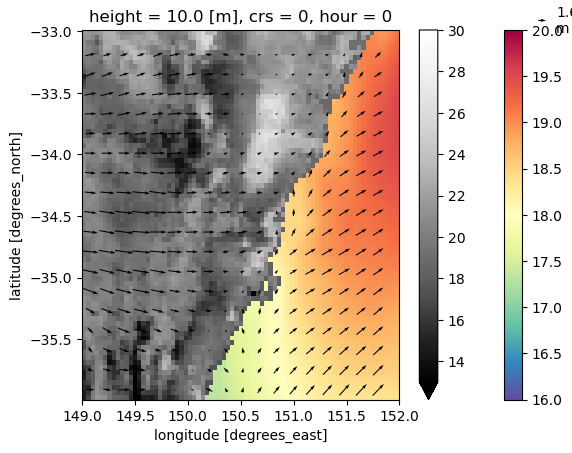

In [51]:
temp = ts_small.groupby(ts_small.time.dt.hour).mean().sel(hour=0)
xr.where(ocean,temp,np.nan).plot(vmin=16,vmax=20,cmap="Spectral_r")
xr.where(ocean,np.nan,temp).plot(cmap="Greys_r",vmin=13,vmax=30)

xr.Dataset({"u":uas_small.groupby(ts_small.time.dt.hour).mean().sel(hour=0),"v":vas_small.groupby(ts_small.time.dt.hour).mean().sel(hour=0)}).\
    coarsen({"lat":4,"lon":4},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v")

Text(0.5, 1.0, '72 sea breeze days during October from BARRA-R2.\nSplit into large and small land-sea temp diff, wind averaged\nover all sea breeze days over Illawarra offshore wind area')

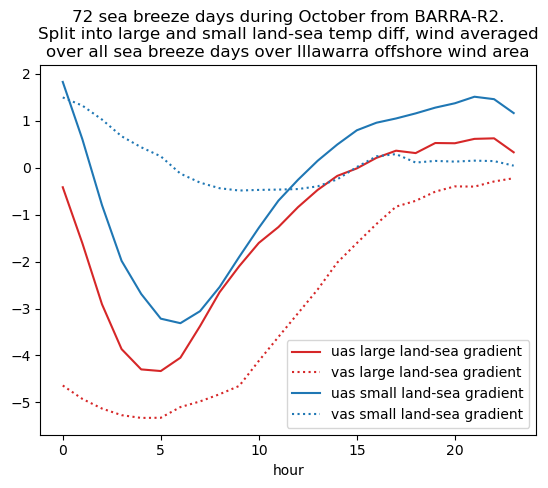

In [38]:
plt.figure()
xr.where(rez_shapes.rez_mask==19, uas_large, np.nan).mean(("lat","lon")).groupby(uas_large.time.dt.hour).mean().plot(label="uas large land-sea gradient",color="tab:red",ls="-")
xr.where(rez_shapes.rez_mask==19, vas_large, np.nan).mean(("lat","lon")).groupby(vas_large.time.dt.hour).mean().plot(label="vas large land-sea gradient",color="tab:red",ls=":")

xr.where(rez_shapes.rez_mask==19, uas_small, np.nan).mean(("lat","lon")).groupby(uas_small.time.dt.hour).mean().plot(label="uas small land-sea gradient",color="tab:blue",ls="-")
xr.where(rez_shapes.rez_mask==19, vas_small, np.nan).mean(("lat","lon")).groupby(vas_small.time.dt.hour).mean().plot(label="vas small land-sea gradient",color="tab:blue",ls=":")

plt.legend()

plt.title("72 sea breeze days during October from BARRA-R2.\nSplit into large and small land-sea temp diff, wind averaged\nover all sea breeze days over Illawarra offshore wind area")

<Axes: ylabel='Frequency'>

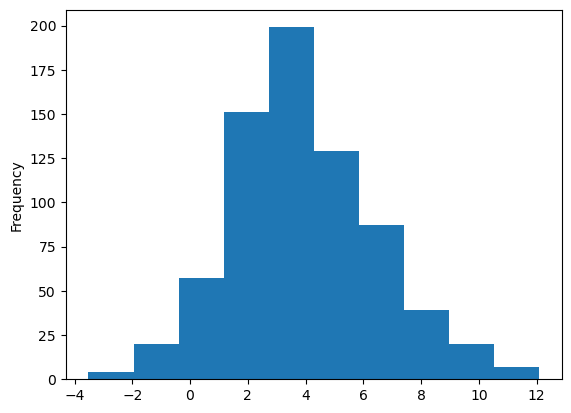

In [46]:
sst_stats.land_sea_diff.plot(kind="hist")